## Introduction
This project performs Exploratory Data Analysis (EDA) on stock market data to understand trends, volatility, and trading patterns.

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df = pd.read_csv("nifty.csv", comment='#', on_bad_lines='skip', engine='python')
df.columns = df.columns.str.strip()
df.head()

,﻿Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,01-JAN-2021,13996.10,14049.85,13991.35,14018.50,258090905,15873.75
1,31-DEC-2020,13970.00,14024.85,13936.45,13981.75,452410109,26305.82
2,30-DEC-2020,13980.90,13997.00,13864.95,13981.95,380681073,24633.12
3,29-DEC-2020,13910.35,13967.60,13859.90,13932.60,439593961,25154.23
4,28-DEC-2020,13815.15,13885.30,13811.55,13873.20,403634030,20923.06


In [22]:
df.shape

(989, 7)

In [23]:
df.info()
df.describe()


<class 'pandas.DataFrame'>
RangeIndex: 989 entries, 0 to 988
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ﻿Date            989 non-null    str    
 1   Open             989 non-null    float64
 2   High             989 non-null    float64
 3   Low              989 non-null    float64
 4   Close            989 non-null    float64
 5   Shares Traded    989 non-null    int64  
 6   Turnover (₹ Cr)  989 non-null    float64
dtypes: float64(5), int64(1), str(1)
memory usage: 54.2 KB


,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
count,989.000000,989.000000,989.000000,989.000000,9.890000e+02,989.000000
mean,17338.671031,17427.505713,17224.575126,17328.852983,4.297183e+08,27893.715875
std,5114.125383,5119.750716,5113.364908,5116.533851,2.091455e+08,8468.368421
min,7735.150000,8036.950000,7511.100000,7610.250000,4.247713e+07,3637.060000
25%,13764.400000,13885.300000,13661.750000,13760.550000,2.666362e+08,21465.330000
50%,16900.650000,17054.300000,16809.650000,16929.600000,3.727770e+08,26611.960000
75%,18719.550000,18781.950000,18632.900000,18701.050000,5.562386e+08,33084.790000
max,26333.700000,26373.200000,26210.050000,26328.550000,1.811564e+09,78522.930000


In [24]:
df.isnull().sum()

Date              0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64

In [25]:
df.ffill(inplace=True)

,﻿Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,01-JAN-2021,13996.10,14049.85,13991.35,14018.50,258090905,15873.75
1,31-DEC-2020,13970.00,14024.85,13936.45,13981.75,452410109,26305.82
2,30-DEC-2020,13980.90,13997.00,13864.95,13981.95,380681073,24633.12
3,29-DEC-2020,13910.35,13967.60,13859.90,13932.60,439593961,25154.23
4,28-DEC-2020,13815.15,13885.30,13811.55,13873.20,403634030,20923.06
...,...,...,...,...,...,...,...
984,17-APR-2025,23401.85,23872.35,23298.55,23851.65,505333905,38450.09
985,16-APR-2025,23344.10,23452.20,23273.05,23437.20,348424960,28102.36
986,15-APR-2025,23368.35,23368.35,23207.00,23328.55,388321931,34216.17
987,11-APR-2025,22695.40,22923.90,22695.40,22828.55,402162001,33683.60


In [26]:
df.isnull().sum()

Date              0
Open               0
High               0
Low                0
Close              0
Shares Traded      0
Turnover (₹ Cr)    0
dtype: int64

In [27]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [32]:
df = df.sort_values(by='date')

df['daily return'] = df['close'].pct_change()

df['ma20'] = df['close'].rolling(20).mean()
df['ma50'] = df['close'].rolling(50).mean()

df['volatility'] = df['daily return'].rolling(20).std()

In [34]:
df = df.sort_values(by='date')

In [36]:
df['daily return'] = df['close'].pct_change()


In [ ]:
df['ma20'] = df['close'].rolling(20).mean()
df['ma50'] = df['close'].rolling(50).mean()

In [38]:
df['volatility'] = df['daily return'].rolling(20).std()

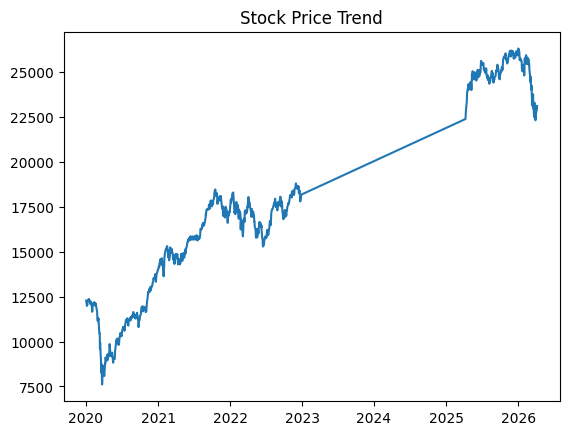

In [40]:
plt.figure()
plt.plot(df['date'], df['close'])
plt.title("Stock Price Trend")
plt.show()

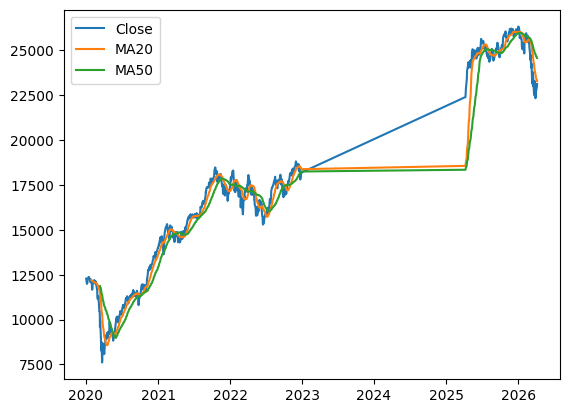

In [41]:
plt.figure()
plt.plot(df['date'], df['close'], label='Close')
plt.plot(df['date'], df['ma20'], label='MA20')
plt.plot(df['date'], df['ma50'], label='MA50')
plt.legend()
plt.show()

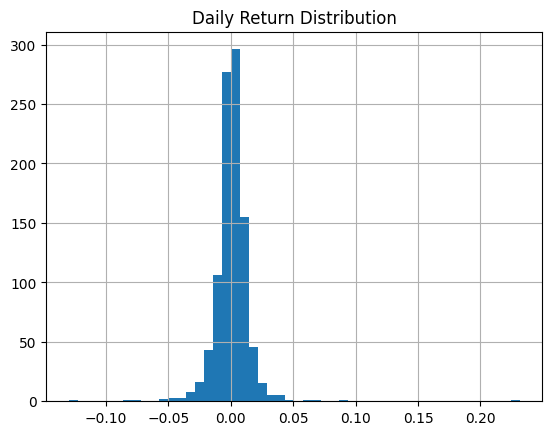

In [43]:
plt.figure()
df['daily return'].hist(bins=50)
plt.title("Daily Return Distribution")
plt.show()

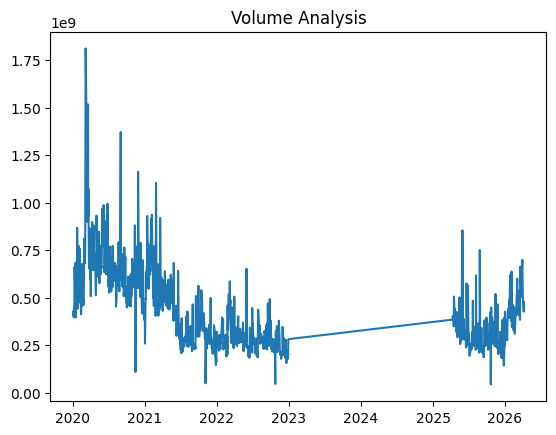

In [44]:
plt.figure()
plt.plot(df['date'], df['shares traded'])
plt.title("Volume Analysis")
plt.show()

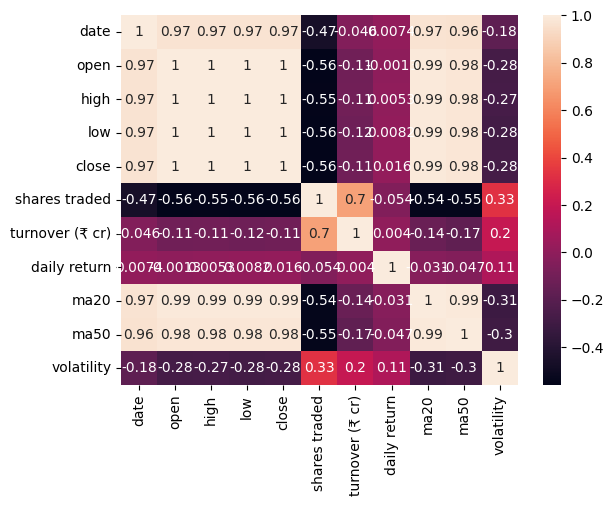

In [45]:
plt.figure()
sns.heatmap(df.corr(), annot=True)
plt.show()

### Insights

1. The stock shows an overall upward/downward trend over time.
2. Moving averages help identify trend direction.
3. Daily returns indicate volatility in stock price.
4. Volume spikes indicate high trading activity.
5. Strong correlation exists between Open and Close prices.

## Dataset Description
The dataset contains historical stock data with more than 1000 rows. 
It includes columns like Date, Open, High, Low.